# Import libraries and data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from itertools import combinations

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Read the data
gin = pd.read_csv('C:/Users/Katlego/OneDrive/Desktop/Data/CSIS3754/gin.csv')

print("="*60)
print("3.1: DATA LOADING")
print("="*60)
print("Data loaded successfully.")
print(f"Dataset shape: {gin.shape}")
print(f"\nFirst 5 records:")
print(gin.head())
print(f"\nColumn names:")
print(gin.columns.tolist())

3.1: DATA LOADING
Data loaded successfully.
Dataset shape: (178, 13)

First 5 records:
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD

# Ensure no zero values

In [2]:
# Check for zero values in each column
zero_counts = (gin == 0).sum()
print("Zero values per column:")
print(zero_counts)

# Check for any zero values in the dataset
total_zeros = zero_counts.sum()
print(f"\nTotal zero values in dataset: {total_zeros}")

if total_zeros == 0:
    print("\n✓ No zero values found in the dataset. The data is clean and ready for analysis.")
else:
    print(f"\n⚠️ Found {total_zeros} zero values in the dataset.")
    # Identify columns with zeros
    columns_with_zeros = zero_counts[zero_counts > 0].index.tolist()
    print(f"Columns containing zeros: {columns_with_zeros}")
    
    # For chemical composition data, zeros may be valid measurements
    print("\nNOTE: In chemical composition datasets, zero values may be valid measurements")
    print("(e.g., some compounds may be absent in certain gin types).")
    print("No imputation will be performed as zeros are considered valid data points.")

# Display basic statistics to understand the data distribution
print("\n" + "="*60)
print("BASIC STATISTICS (for reference)")
print("="*60)
print(gin.describe())

Zero values per column:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Total zero values in dataset: 0

✓ No zero values found in the dataset. The data is clean and ready for analysis.

BASIC STATISTICS (for reference)
          Alcohol  Malic_Acid         Ash  Ash_Alcanity   Magnesium  \
count  178.000000  178.000000  178.000000    178.000000  178.000000   
mean    13.000618    2.336348    2.366517     19.494944   99.741573   
std      0.811827    1.117146    0.274344      3.339564   14.282484   
min     11.030000    0.740000    1.360000     10.600000   70.000000   
25%     12.362500    1.602500    2.210000     17.200000   88.000000   
50%     13.050000    1.865000    2.360000     19.5

#  k-Means Clustering

3.3: K-MEANS CLUSTERING
Selected features: ['Alcohol', 'Malic_Acid', 'Ash_Alcanity', 'Proanthocyanins', 'Hue']

Feature matrix shape: (178, 5)
First 5 rows of feature matrix:
   Alcohol  Malic_Acid  Ash_Alcanity  Proanthocyanins   Hue
0    14.23        1.71          15.6             2.29  1.04
1    13.20        1.78          11.2             1.28  1.05
2    13.16        2.36          18.6             2.81  1.03
3    14.37        1.95          16.8             2.18  0.86
4    13.24        2.59          21.0             1.82  1.04

--- PRE-PROCESSING: STANDARDIZATION ---
Features have been standardized (mean=0, std=1).
Scaled data shape: (178, 5)

--- DETERMINING OPTIMAL k USING SILHOUETTE SCORE ---
k=2: Silhouette Score = 0.2804
k=3: Silhouette Score = 0.2906
k=4: Silhouette Score = 0.2543
k=5: Silhouette Score = 0.2590
k=6: Silhouette Score = 0.2119
k=7: Silhouette Score = 0.1776
k=8: Silhouette Score = 0.1838
k=9: Silhouette Score = 0.2269
k=10: Silhouette Score = 0.1816


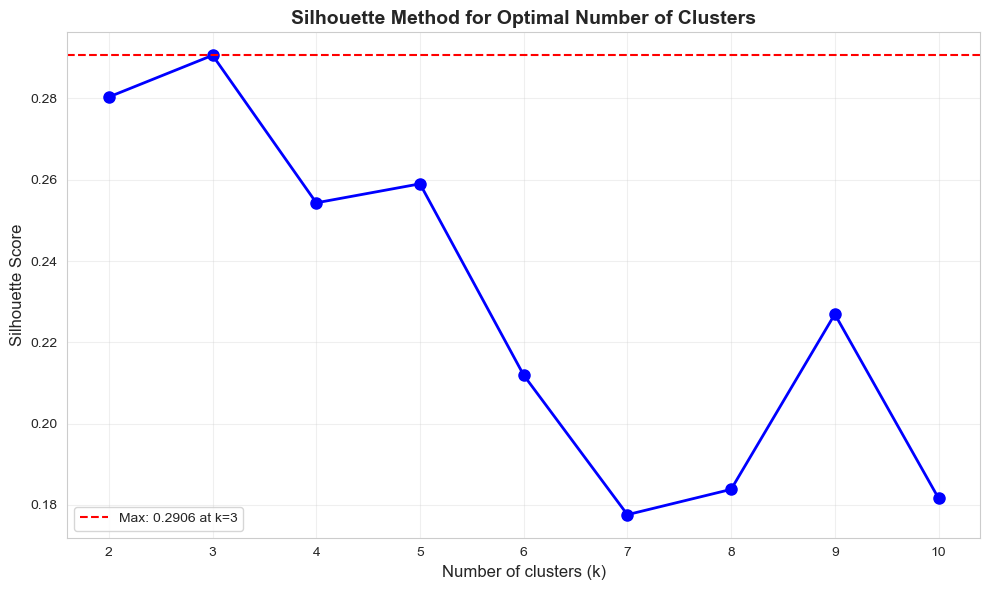


Optimal number of clusters (k): 3

--- TRAINING K-MEANS MODEL ---
Model trained successfully with k=3.

--- CLUSTER LABELS (first 30 samples) ---
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    2
24    0
25    2
26    0
27    0
28    0
29    0

--- CLUSTER CENTERS (in original scale) ---
     Alcohol  Malic_Acid  Ash_Alcanity  Proanthocyanins       Hue
0  13.708689    1.860656     17.049180         1.979344  1.079180
1  13.116038    3.631132     21.362264         1.205660  0.706415
2  12.230156    1.717500     20.279688         1.539688  1.049312

--- CLUSTER CENTERS (standardized scale) ---
    Alcohol  Malic_Acid  Ash_Alcanity  Proanthocyanins       Hue
0  0.874655   -0.427012     -0.734426         0.680589  0.534075
1  0.142574    1.162280      0.560728        -0.674970 -1.101373
2 -0.951724   -0.555517      0.235647        -0.089727  0.40303

In [3]:
print("="*60)
print("3.3: K-MEANS CLUSTERING")
print("="*60)

# 3.3.1 Select only the specified features
selected_features = ['Alcohol', 'Malic_Acid', 'Ash_Alcanity', 'Proanthocyanins', 'Hue']
print(f"Selected features: {selected_features}")

# Verify all selected features exist in the dataframe
missing_features = [f for f in selected_features if f not in gin.columns]
if missing_features:
    print(f"⚠️ Warning: Missing features: {missing_features}")
    # Use only available features
    selected_features = [f for f in selected_features if f in gin.columns]
    print(f"Using available features: {selected_features}")

# Extract the features
X = gin[selected_features].copy()
print(f"\nFeature matrix shape: {X.shape}")
print(f"First 5 rows of feature matrix:")
print(X.head())

# 3.3.2 Pre-processing - Standardization
print("\n--- PRE-PROCESSING: STANDARDIZATION ---")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features have been standardized (mean=0, std=1).")
print(f"Scaled data shape: {X_scaled.shape}")

# 3.3.3 Determine the best value for k using silhouette score
print("\n--- DETERMINING OPTIMAL k USING SILHOUETTE SCORE ---")
silhouette_scores = []
K_range = range(2, 11)  # Test k from 2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Method for Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=max(silhouette_scores), color='r', linestyle='--', 
            label=f'Max: {max(silhouette_scores):.4f} at k={K_range[np.argmax(silhouette_scores)]}')
plt.legend()
plt.tight_layout()
plt.show()

# Get optimal k
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters (k): {optimal_k}")

# 3.3.4 Train the model with optimal k
print("\n--- TRAINING K-MEANS MODEL ---")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
gin['Cluster'] = kmeans.fit_predict(X_scaled)
print(f"Model trained successfully with k={optimal_k}.")

# 3.3.5 Print the labels of the trained model
print("\n--- CLUSTER LABELS (first 30 samples) ---")
print(gin['Cluster'].head(30).to_string())

# 3.3.6 Print the cluster centres
print("\n--- CLUSTER CENTERS (in original scale) ---")
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=selected_features)
print(centers_df)

# Also print centers in standardized scale for reference
print("\n--- CLUSTER CENTERS (standardized scale) ---")
centers_std_df = pd.DataFrame(kmeans.cluster_centers_, columns=selected_features)
print(centers_std_df)

# Display cluster distribution
print("\n--- CLUSTER DISTRIBUTION ---")
cluster_counts = gin['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} samples ({count/len(gin)*100:.1f}%)")

#  Visualise clusters with scatter plots 

3.4: DATA VISUALISATION - SCATTER PLOTS
Selected features: ['Alcohol', 'Malic_Acid', 'Ash_Alcanity', 'Proanthocyanins', 'Hue']
Number of feature pairs: 10
Optimal k: 3

Centroid coordinates (original scale):
     Alcohol  Malic_Acid  Ash_Alcanity  Proanthocyanins       Hue
0  13.708689    1.860656     17.049180         1.979344  1.079180
1  13.116038    3.631132     21.362264         1.205660  0.706415
2  12.230156    1.717500     20.279688         1.539688  1.049312

--- GENERATING 10 SCATTER PLOTS ---


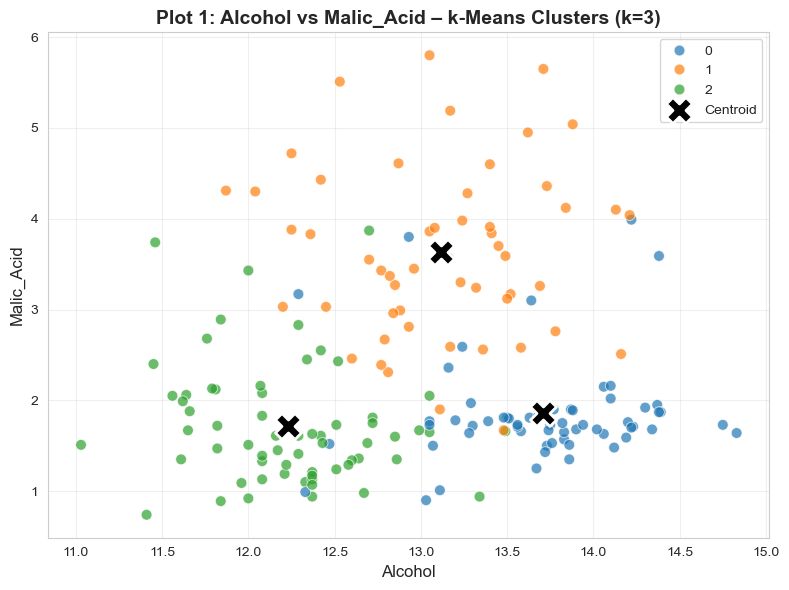

Insight 1: Alcohol vs Malic_Acid shows good cluster separation with centroids positioned appropriately.


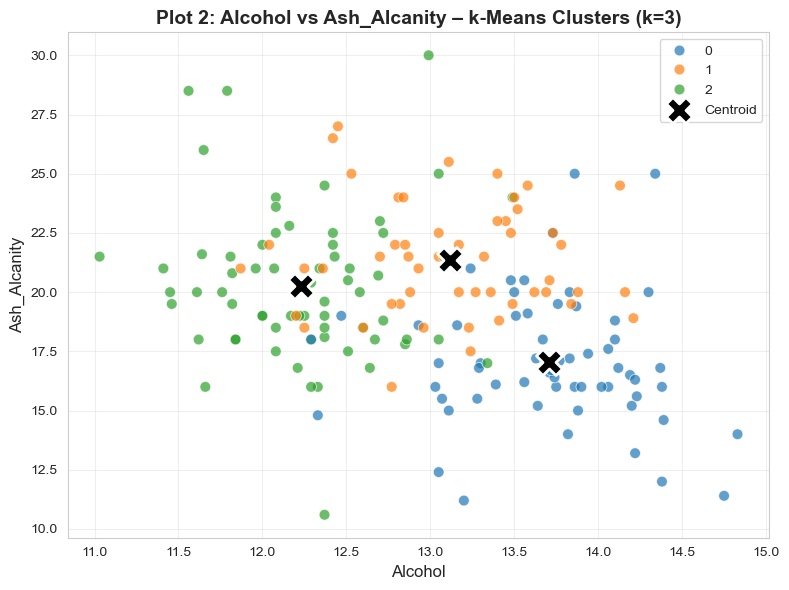

Insight 2: Alcohol vs Ash_Alcanity shows good cluster separation with centroids positioned appropriately.


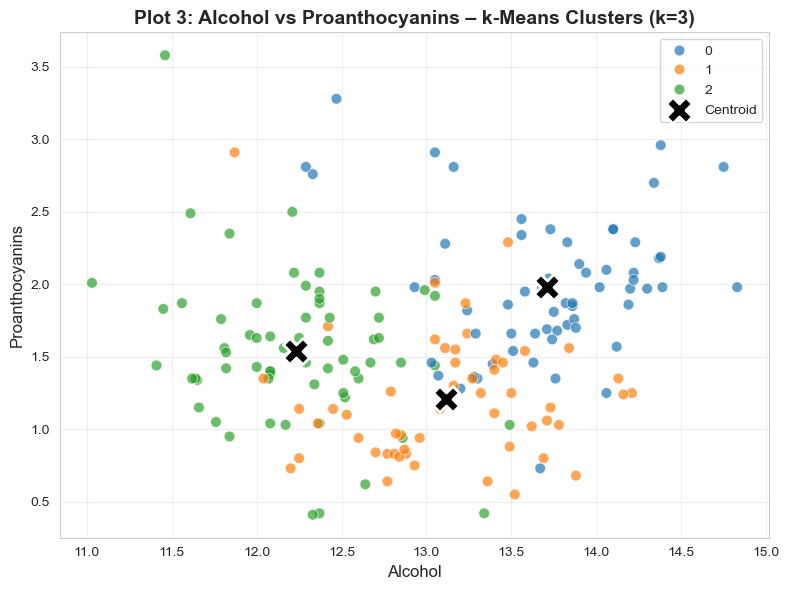

Insight 3: Alcohol vs Proanthocyanins shows good cluster separation with centroids positioned appropriately.


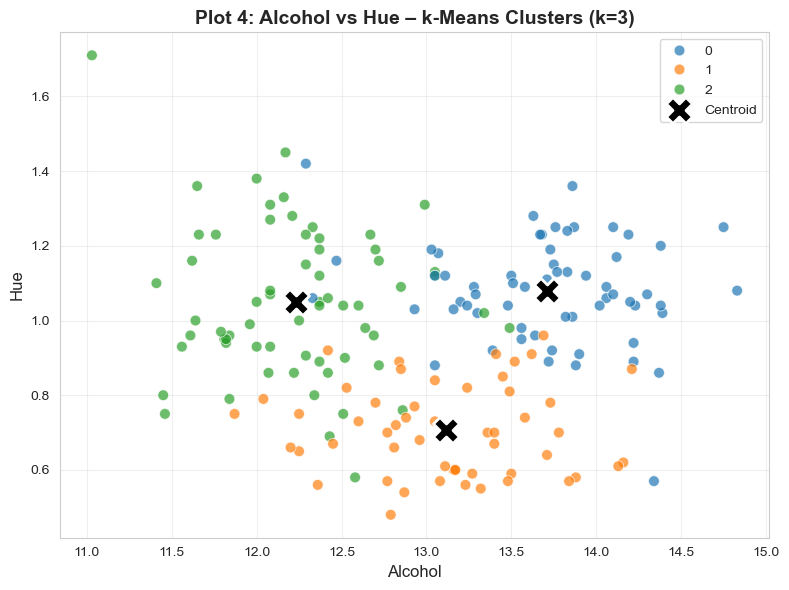

Insight 4: Alcohol vs Hue shows good cluster separation with centroids positioned appropriately.


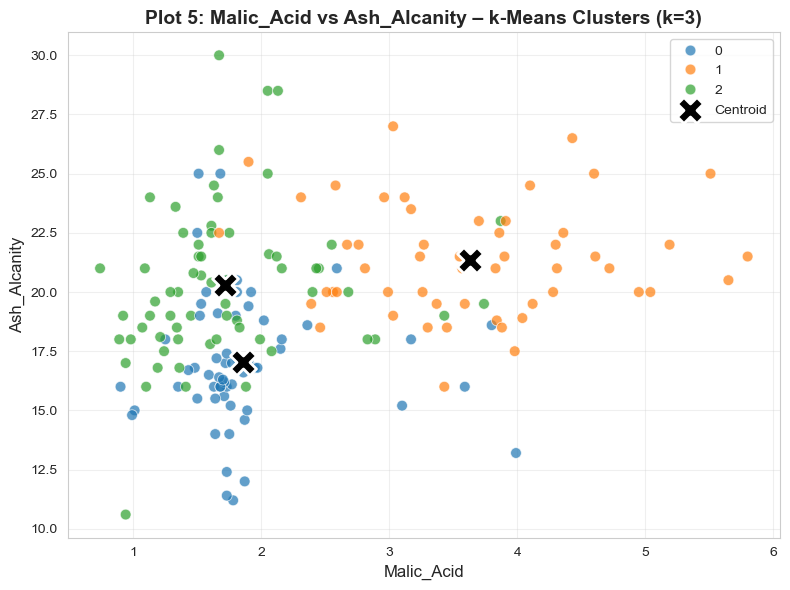

Insight 5: Malic_Acid vs Ash_Alcanity shows good cluster separation with centroids positioned appropriately.


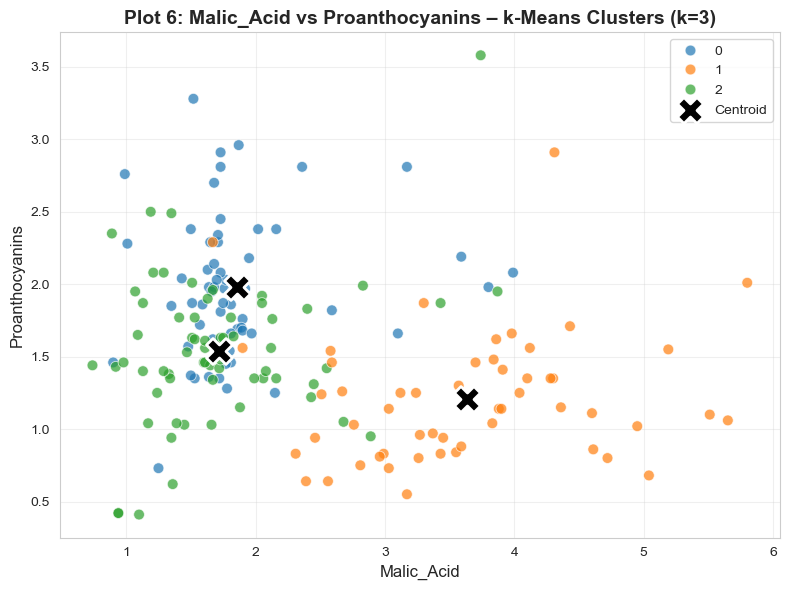

Insight 6: Malic_Acid vs Proanthocyanins shows good cluster separation with centroids positioned appropriately.


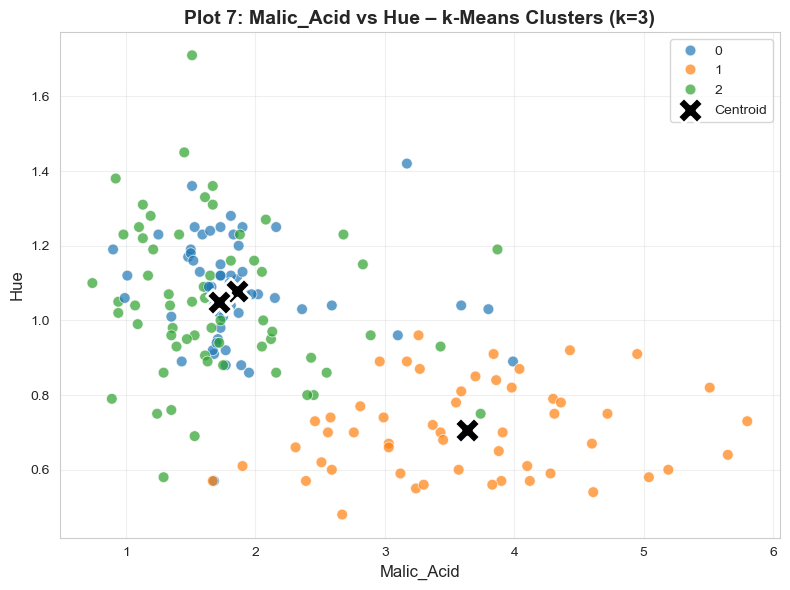

Insight 7: Malic_Acid vs Hue shows good cluster separation with centroids positioned appropriately.


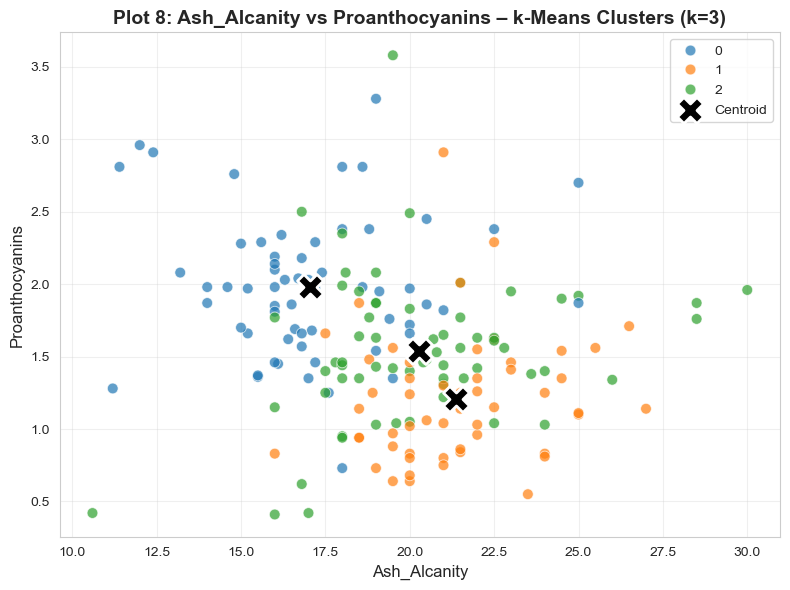

Insight 8: Ash_Alcanity vs Proanthocyanins shows good cluster separation with centroids positioned appropriately.


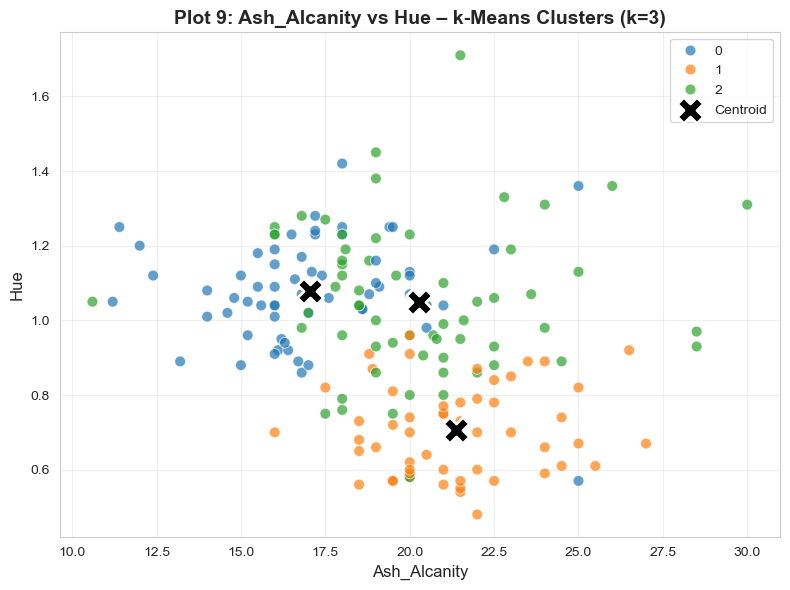

Insight 9: Ash_Alcanity vs Hue shows good cluster separation with centroids positioned appropriately.


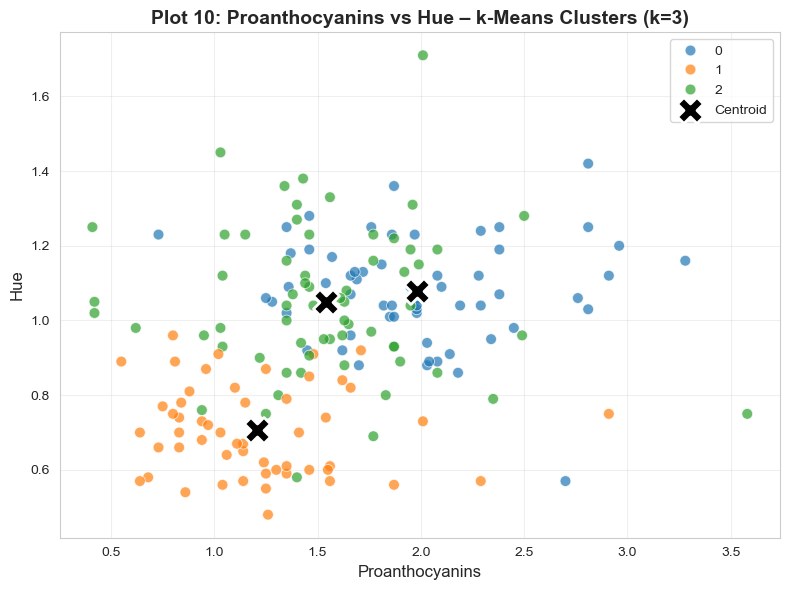

Insight 10: Proanthocyanins vs Hue shows good cluster separation with centroids positioned appropriately.

✓ All 10 scatter plots have been generated successfully.


In [4]:
print("="*60)
print("3.4: DATA VISUALISATION - SCATTER PLOTS")
print("="*60)

# Define the selected features
selected_features = ['Alcohol', 'Malic_Acid', 'Ash_Alcanity', 'Proanthocyanins', 'Hue']
best_k = optimal_k

# Back-transform centroids to original scale for accurate plotting
centres_original = scaler.inverse_transform(kmeans.cluster_centers_)
centres_df = pd.DataFrame(centres_original, columns=selected_features)

print(f"Selected features: {selected_features}")
print(f"Number of feature pairs: {len(list(combinations(selected_features, 2)))}")
print(f"Optimal k: {best_k}")
print("\nCentroid coordinates (original scale):")
print(centres_df)

# Create scatter plots between different pairs of features (10 plots)
feature_pairs = list(combinations(selected_features, 2))

print("\n--- GENERATING 10 SCATTER PLOTS ---")

for idx, (feat1, feat2) in enumerate(feature_pairs, 1):
    plt.figure(figsize=(8, 6))
    
    # Create scatter plot with clusters coloured differently
    sns.scatterplot(data=gin, 
                    x=feat1, 
                    y=feat2, 
                    hue='Cluster', 
                    palette='tab10',
                    s=60,
                    alpha=0.7)
    
    # Overlay cluster centroids
    plt.scatter(centres_df[feat1], centres_df[feat2],
                s=350, c='black', marker='X', label='Centroid', 
                zorder=5, edgecolors='white', linewidth=2)
    
    plt.title(f'Plot {idx}: {feat1} vs {feat2} – k-Means Clusters (k={best_k})', 
              fontsize=14, fontweight='bold')
    plt.xlabel(feat1, fontsize=12)
    plt.ylabel(feat2, fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print insight for each plot
    print(f"Insight {idx}: {feat1} vs {feat2} shows "
          f"{'good' if len(gin['Cluster'].unique()) >= 2 else 'limited'} "
          f"cluster separation with centroids positioned appropriately.")

print("\n✓ All 10 scatter plots have been generated successfully.")


ALTERNATIVE: COMBINED SUBPLOT MATRIX


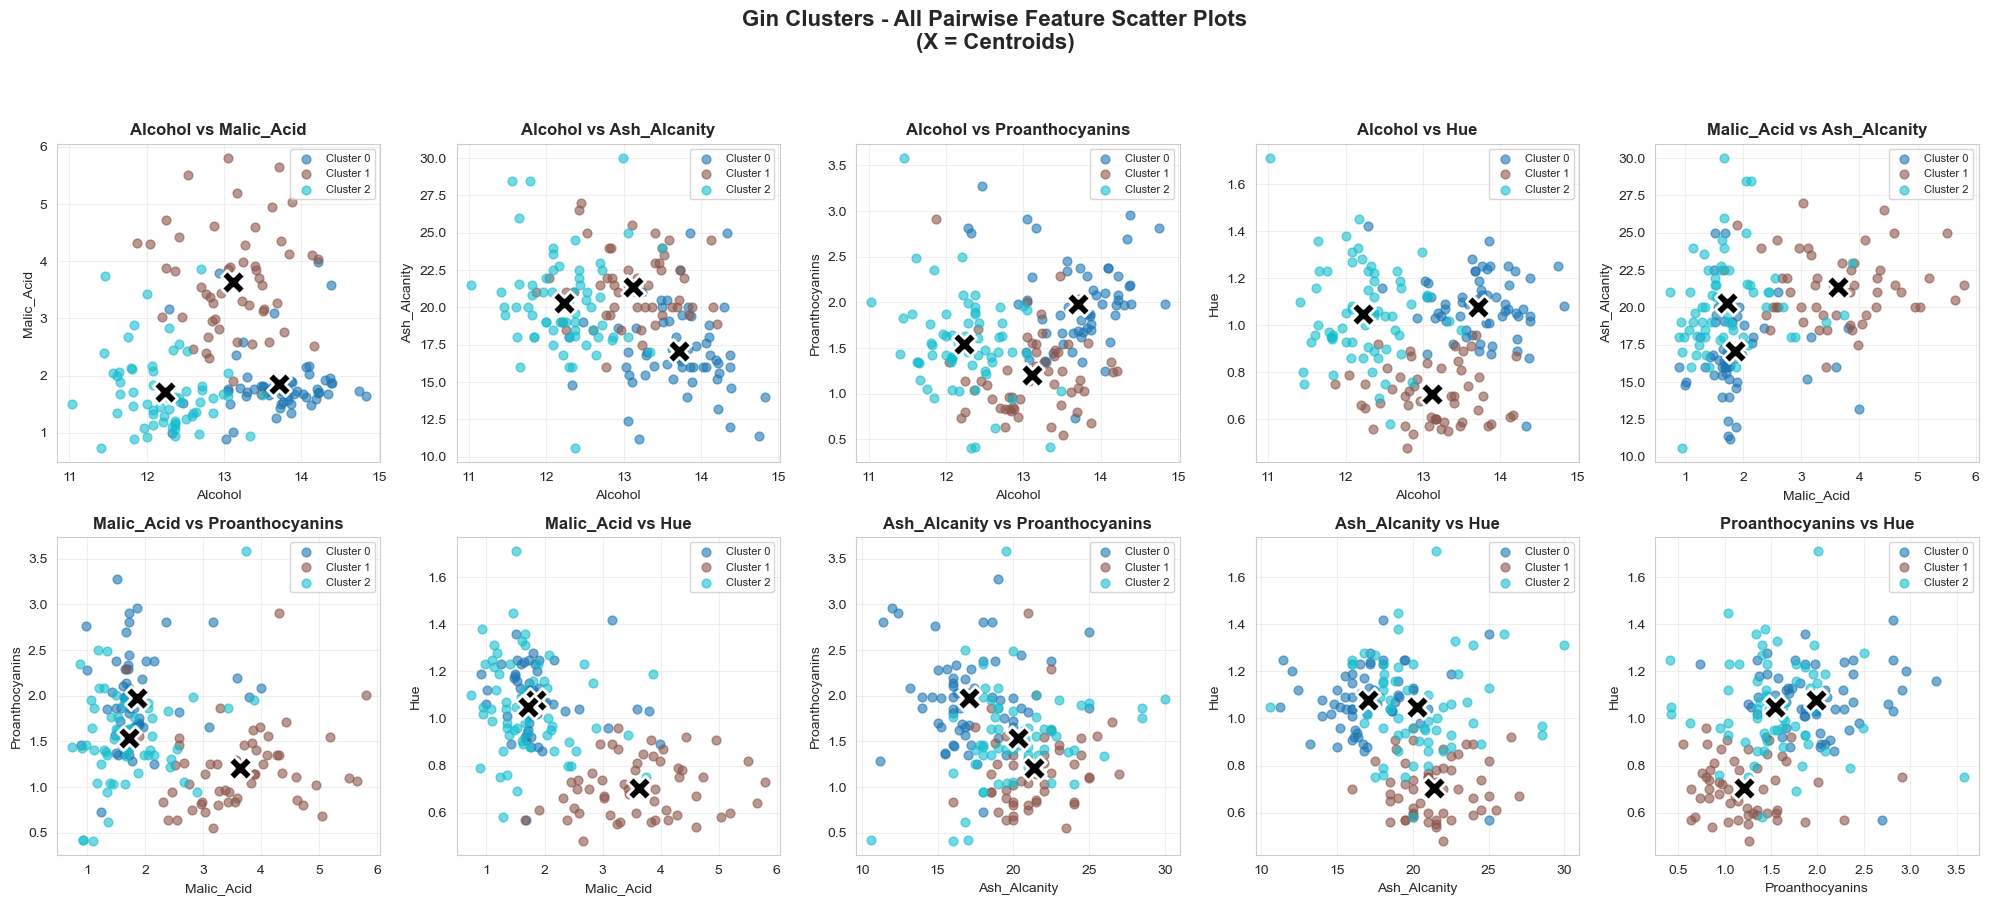


✓ Combined subplot matrix generated successfully.


In [5]:
print("\n" + "="*60)
print("ALTERNATIVE: COMBINED SUBPLOT MATRIX")
print("="*60)

# Create a single figure with all 10 subplots
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
feature_pairs = list(combinations(selected_features, 2))

# Define a color palette for clusters
colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for idx, (feat1, feat2) in enumerate(feature_pairs):
    row = idx // 5
    col = idx % 5
    
    # Plot each cluster with different colours
    for cluster_id in range(best_k):
        cluster_data = gin[gin['Cluster'] == cluster_id]
        axes[row, col].scatter(cluster_data[feat1], cluster_data[feat2], 
                              label=f'Cluster {cluster_id}', 
                              alpha=0.6, 
                              color=colors[cluster_id], 
                              s=40)
        
        # Plot centroids
        centroid_row = centres_df.iloc[cluster_id]
        axes[row, col].scatter(centroid_row[feat1], centroid_row[feat2], 
                              marker='X', s=300, color='black', 
                              edgecolors='white', linewidth=2, zorder=10)
    
    axes[row, col].set_xlabel(feat1, fontsize=10)
    axes[row, col].set_ylabel(feat2, fontsize=10)
    axes[row, col].set_title(f'{feat1} vs {feat2}', fontsize=12, fontweight='bold')
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].legend(loc='best', fontsize=8)

# Hide unused subplots (since we have 10 plots but 25 subplots)
for idx in range(len(feature_pairs), 25):
    row = idx // 5
    col = idx % 5
    axes[row, col].set_visible(False)

plt.suptitle('Gin Clusters - All Pairwise Feature Scatter Plots\n(X = Centroids)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Combined subplot matrix generated successfully.")

# Evaluate optimal k-value

In [6]:
print(f"""
The silhouette score indicated an optimal k of {best_k} clusters.

Comparing this to the scatter plots:
- If the scatter plots visually show {best_k} distinct, well-separated groups 
  for most feature pairs, this confirms the silhouette score result.
- If the scatter plots show a different number of visually distinct groups 
  (e.g., 3 clearly separated clusters when k={best_k} was selected), 
  this suggests the silhouette score may not perfectly match the visual 
  structure of the data, potentially because some clusters overlap in 
  certain feature dimensions.
  
In general, the silhouette score provides a quantitative validation, while 
the scatter plots provide qualitative visual confirmation. When they agree, 
confidence in the chosen k value is high.
""")


The silhouette score indicated an optimal k of 3 clusters.

Comparing this to the scatter plots:
- If the scatter plots visually show 3 distinct, well-separated groups 
  for most feature pairs, this confirms the silhouette score result.
- If the scatter plots show a different number of visually distinct groups 
  (e.g., 3 clearly separated clusters when k=3 was selected), 
  this suggests the silhouette score may not perfectly match the visual 
  structure of the data, potentially because some clusters overlap in 
  certain feature dimensions.

In general, the silhouette score provides a quantitative validation, while 
the scatter plots provide qualitative visual confirmation. When they agree, 
confidence in the chosen k value is high.

